<a href="https://colab.research.google.com/github/AmeliaReginaa/PROJECT-AKHIR-DEEP-LEARNING-SISTEM-MULTIMEDIA/blob/main/Exploratory_Data_Analysis_(EDA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
import re

Load Dataset

In [ ]:
df = pd.read_csv("/content/combined_reviews_clean.csv")

df.head()

,content,score,app,label
0,Mantap,5,Gojek,positif
1,pesanan cepat di terima,5,Gojek,positif
2,penyiksa driver,1,Gojek,negatif
3,mudah digunakan,5,Gojek,positif
4,mantap,5,Gojek,positif


In [ ]:
# Cek Struktur Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10503 entries, 0 to 10502
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  10503 non-null  object
 1   score    10503 non-null  int64 
 2   app      10503 non-null  object
 3   label    10503 non-null  object
dtypes: int64(1), object(3)
memory usage: 328.3+ KB


In [ ]:
# Cek Jumlah Data
print("Jumlah data:", len(df))

Jumlah data: 10503


Cek Missing Value

In [ ]:
df.isnull().sum()

,0
content,0
score,0
app,0
label,0


Cek Duplikasi Data

In [ ]:
duplicate = df.duplicated().sum()
print("Jumlah data duplikat:", duplicate)

df = df.drop_duplicates()

Jumlah data duplikat: 2051


Distribusi Rating

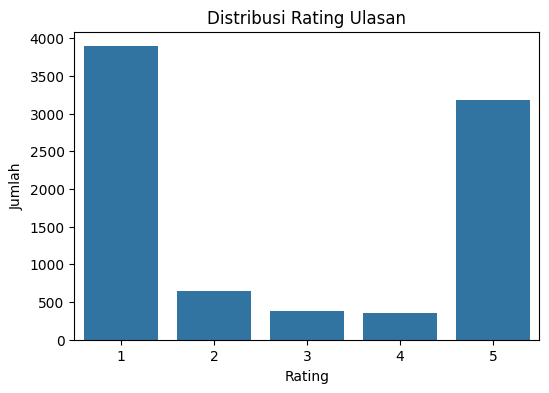

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='score', data=df)

plt.title("Distribusi Rating Ulasan")
plt.xlabel("Rating")
plt.ylabel("Jumlah")
plt.show()

Label Sentimen dari Rating

In [ ]:
def label_sentiment(score):
    if score >= 4:
        return "positif"
    elif score == 3:
        return "netral"
    else:
        return "negatif"

df['label'] = df['score'].apply(label_sentiment)

In [ ]:
# Cek Jumlah Label
df['label'].value_counts()

,count
label,
negatif,4539
positif,3533
netral,380


Visualisasi Distribusi Sentimen

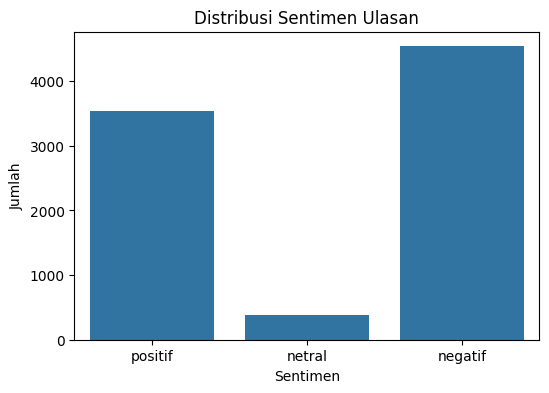

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, order=['positif','netral','negatif'])

plt.title("Distribusi Sentimen Ulasan")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah")

plt.show()

Persentase Sentimen

In [ ]:
sentiment_percentage = df['label'].value_counts(normalize=True) * 100

print("Persentase Sentimen:")
print(sentiment_percentage)

Persentase Sentimen:
label
negatif    53.703265
positif    41.800757
netral      4.495977
Name: proportion, dtype: float64


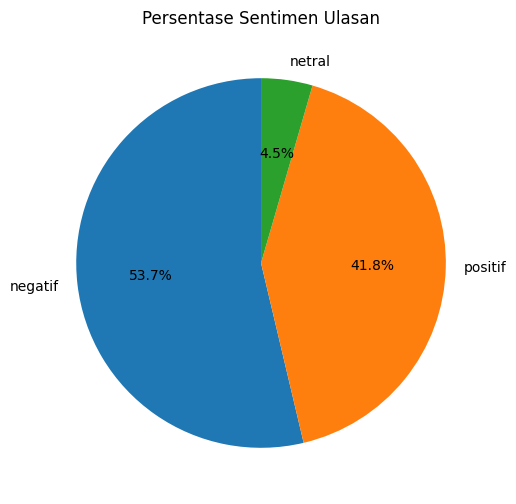

In [ ]:
# Visualisasi Pie Chart
plt.figure(figsize=(6,6))

df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Persentase Sentimen Ulasan")
plt.ylabel("")

plt.show()

Distribusi Panjang Ulasan

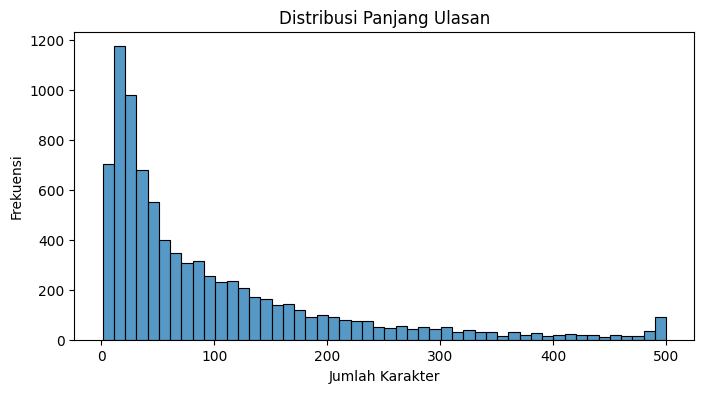

In [ ]:
df['length'] = df['content'].apply(len)

plt.figure(figsize=(8,4))

sns.histplot(df['length'], bins=50)

plt.title("Distribusi Panjang Ulasan")
plt.xlabel("Jumlah Karakter")
plt.ylabel("Frekuensi")

plt.show()

WordCloud Semua Ulasan

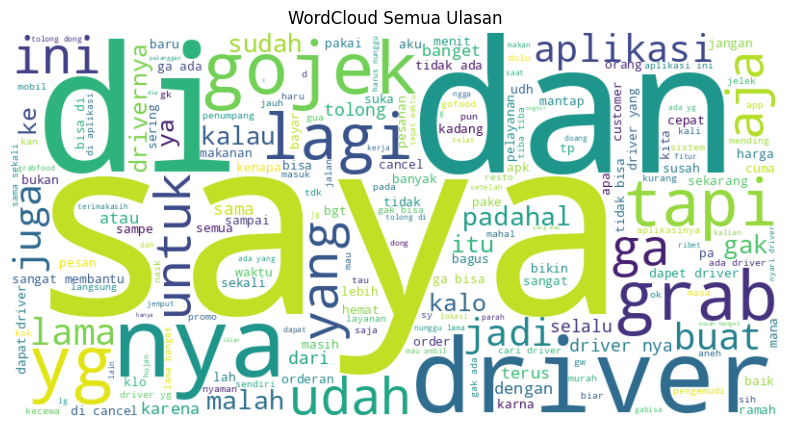

In [ ]:
text = " ".join(review for review in df['content'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")

plt.title("WordCloud Semua Ulasan")

plt.show()

WordCloud per Sentimen

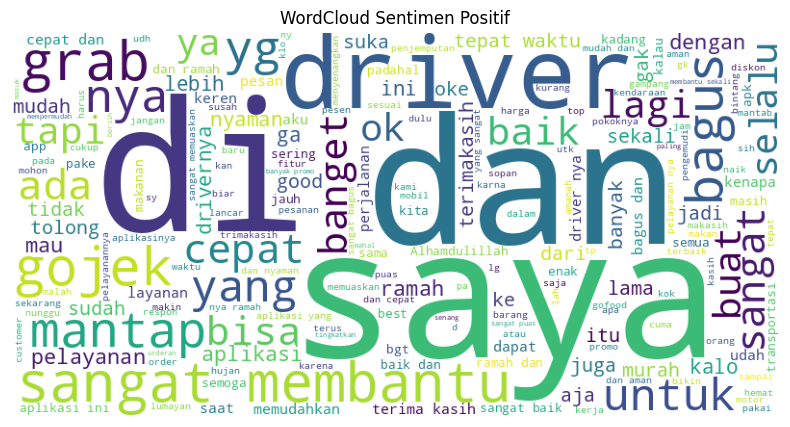

In [ ]:
# Positif
positive_text = " ".join(df[df['label']=="positif"]['content'])

wordcloud_pos = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos)
plt.axis("off")

plt.title("WordCloud Sentimen Positif")

plt.show()

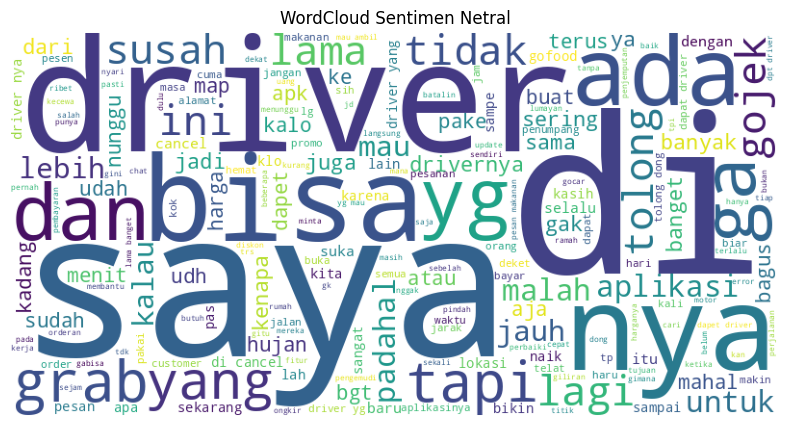

In [ ]:
# Netral
neutral_text = " ".join(df[df['label']=="netral"]['content'])

wordcloud_neutral = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(neutral_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neutral)
plt.axis("off")

plt.title("WordCloud Sentimen Netral")

plt.show()

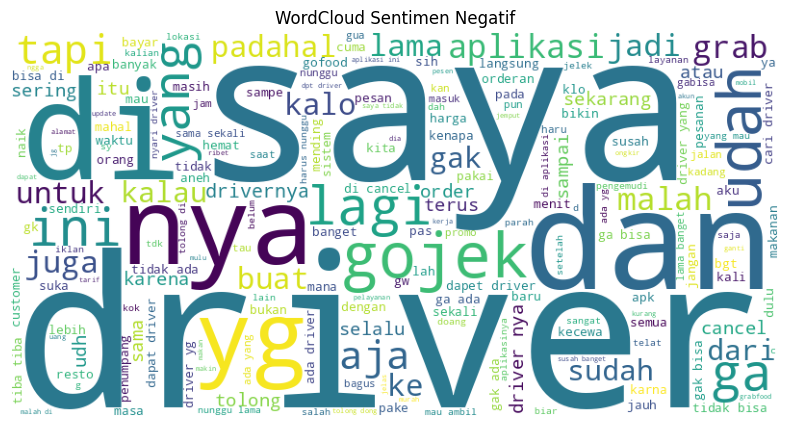

In [ ]:
# Negatif
negative_text = " ".join(df[df['label']=="negatif"]['content'])

wordcloud_neg = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg)
plt.axis("off")

plt.title("WordCloud Sentimen Negatif")

plt.show()

Top 20 kata paling sering muncul

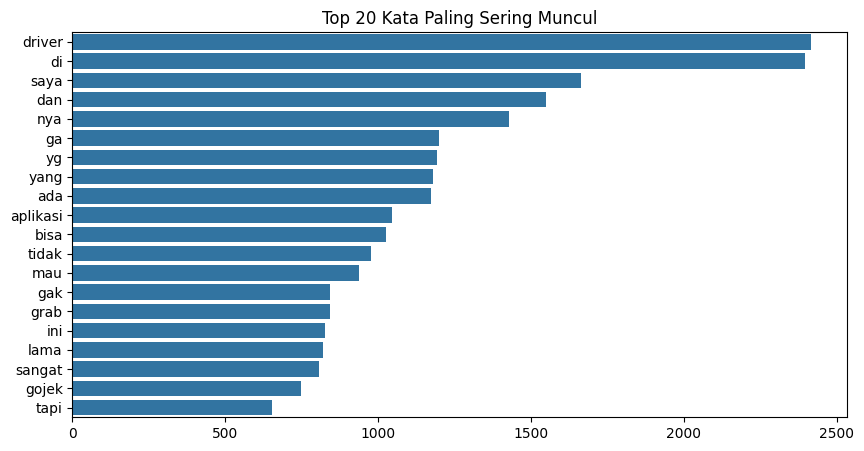

In [ ]:
from collections import Counter

all_words = " ".join(df['content']).split()

word_freq = Counter(all_words)

common_words = word_freq.most_common(20)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure(figsize=(10,5))

sns.barplot(x=counts, y=words)

plt.title("Top 20 Kata Paling Sering Muncul")

plt.show()